# Embedding predictions of ogbn network classes

In this file I will focus on making class predictions through the use of node_feature embedding space.

The embedding vectors have a dimension of 128, and there are about 170k nodes in total.

## Imports and dataset download

In [2]:
!pip install ogb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.7 MB/s eta 0:00:00


In [40]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, accuracy_score, f1_score
from ogb.nodeproppred import NodePropPredDataset
import numpy as np
import torch
import time

In [4]:
# Save original torch.load function
_torch_load_func = torch.load

def custom_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _torch_load_func(*args, **kwargs)

torch.load = custom_torch_load

dataset = NodePropPredDataset(name='ogbn-arxiv')
graph, y = dataset[0]

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:03<00:00, 23.65it/s]


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 6831.11it/s]

Saving...


In [5]:
y = y.squeeze()
y

array([ 4,  5, 28, ..., 10,  4,  1])

In [6]:
len(np.where(graph["node_year"] == 2017)[0])

21442

In [7]:
len(np.where(graph["node_year"] == 2018)[0])

29799

In [8]:
len(np.where(graph["node_year"] == 2019)[0])

39711

In [9]:
graph["node_feat"]

array([[-0.057943, -0.05253 , -0.072603, ...,  0.173364, -0.172796,
        -0.140059],
       [-0.1245  , -0.070665, -0.325202, ...,  0.068524, -0.372111,
        -0.301036],
       [-0.080242, -0.023328, -0.183787, ...,  0.109919,  0.117589,
        -0.139883],
       ...,
       [-0.22053 , -0.036568, -0.402199, ...,  0.11336 , -0.161393,
        -0.145171],
       [-0.138236,  0.040885, -0.251811, ..., -0.08929 , -0.041253,
        -0.376132],
       [-0.029875,  0.268417, -0.161124, ...,  0.120807,  0.077647,
        -0.091018]], dtype=float32)

In [10]:
split_idx = dataset.get_idx_split()

train_idx = split_idx["train"]

In [11]:
len(train_idx)

90941

In [12]:
test_idx = split_idx["test"]

In [13]:
test_idx[0]

np.int64(346)

In [14]:
len(test_idx)

48603

In [15]:
valid_idx = split_idx["valid"]

/tmp/ipykernel_2463/1144259599.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_names, y=split_lengths, palette='viridis')


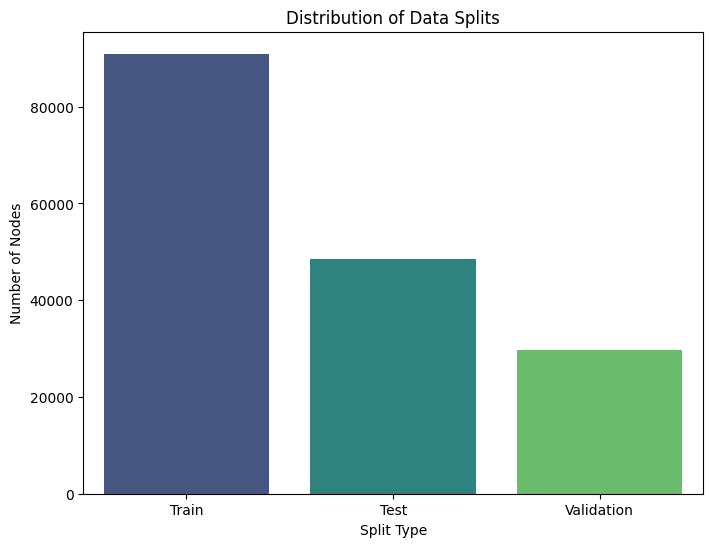

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

split_names = ['Train', 'Test', 'Validation']
split_lengths = [len(train_idx), len(test_idx), len(valid_idx)]

plt.figure(figsize=(8, 6))
sns.barplot(x=split_names, y=split_lengths, palette='viridis')
plt.title('Distribution of Data Splits')
plt.ylabel('Number of Nodes')
plt.xlabel('Split Type')
plt.show()

## Embedding predictions

In [17]:
# 1. KROK: Příprava VŠECH reprezentantů roztříděných podle SKUTEČNÝCH tříd z y
class_reprezentants_feats = {}
class_reprezentants_norms = {}

for cls in range(40): # Dataset ogbn-arxiv má 40 tříd
    # Filtrujeme pouze trénovací uzly, jejichž skutečná třída je `cls`
    idx_in_train = np.where(y[train_idx] == cls)[0]
    cls_nodes = train_idx[idx_in_train]

    # Uložíme si celou matici embeddingů pro danou třídu (a její normy)
    feats = graph["node_feat"][cls_nodes]
    class_reprezentants_feats[cls] = feats
    class_reprezentants_norms[cls] = np.linalg.norm(feats, axis=1)

In [18]:
# 1. Příprava matice testovacích dat a jejích norem
test_feats = graph["node_feat"][test_idx]
test_norms = np.linalg.norm(test_feats, axis=1, keepdims=True)

# 2. Připravíme si pole pro ukládání výsledků
# Vytvoříme matice plné nul pro Max a Mean podobnosti (tvar: počet_test_uzlů x 40 tříd)
num_test_nodes = len(test_idx)
all_max_sims = np.zeros((num_test_nodes, 40))
all_mean_sims = np.zeros((num_test_nodes, 40))

In [19]:
import numpy as np

for cls in range(40):
    cls_feats = class_reprezentants_feats[cls]
    cls_norms = class_reprezentants_norms[cls]

    dot = test_feats @ cls_feats.T

    sims = dot / (test_norms * cls_norms + 1e-10)

    all_max_sims[:, cls] = sims.max(axis=1)
    all_mean_sims[:, cls] = sims.mean(axis=1)

preds_zadani = all_max_sims.argmax(axis=1)

In [20]:
y_true = y[test_idx]

nmi = normalized_mutual_info_score(y_true, preds_zadani)
ari = adjusted_rand_score(y_true, preds_zadani)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.2355
ARI: 0.2404


In [21]:
correct_predictions = np.sum(preds_zadani == y[test_idx])
accuracy = correct_predictions / num_test_nodes
print(f"Accuracy on the test set: {accuracy:.4f}")

Accuracy on the test set: 0.4243


In [22]:
all_max_sims[0]

array([0.88054168, 0.89079487, 0.89375961, 0.90045625, 0.87510312,
       0.90886605, 0.8938995 , 0.87755865, 0.87457585, 0.88958889,
       0.93041539, 0.89477491, 0.82929444, 0.90711004, 0.87251168,
       0.83887666, 0.92059147, 0.87126458, 0.85872912, 0.9004066 ,
       0.88475031, 0.8591944 , 0.89877719, 0.89140022, 0.94543743,
       0.8849225 , 0.91803008, 0.91647178, 0.89889246, 0.8658036 ,
       0.93012476, 0.91528255, 0.87499839, 0.86593252, 0.90901339,
       0.85662127, 0.9075895 , 0.90618056, 0.86981231, 0.87422079])

## LLM Predictions

#### Imports and defs

In [30]:
import os
import pandas as pd
import numpy as np

labels_mapping_path = os.path.join(dataset.root, "mapping", "labelidx2arxivcategeory.csv.gz")

df_id_to_label = pd.read_csv(labels_mapping_path, compression='gzip')

id_to_label = df_id_to_label.to_dict()["arxiv category"]
label_to_id = {v: k for k, v in id_to_label.items()}

In [31]:
# Získáme seznam všech textových názvů (např. 'arxiv cs ai', 'arxiv cs cv' atd.)
seznam_trid = list(id_to_label.values())

# LLM získá na vstupu tento seznam
print(f"Počet tříd pro LLM: {len(seznam_trid)}")

Počet tříd pro LLM: 40


In [32]:
label_to_id.items()

dict_items([('arxiv cs na', 0), ('arxiv cs mm', 1), ('arxiv cs lo', 2), ('arxiv cs cy', 3), ('arxiv cs cr', 4), ('arxiv cs dc', 5), ('arxiv cs hc', 6), ('arxiv cs ce', 7), ('arxiv cs ni', 8), ('arxiv cs cc', 9), ('arxiv cs ai', 10), ('arxiv cs ma', 11), ('arxiv cs gl', 12), ('arxiv cs ne', 13), ('arxiv cs sc', 14), ('arxiv cs ar', 15), ('arxiv cs cv', 16), ('arxiv cs gr', 17), ('arxiv cs et', 18), ('arxiv cs sy', 19), ('arxiv cs cg', 20), ('arxiv cs oh', 21), ('arxiv cs pl', 22), ('arxiv cs se', 23), ('arxiv cs lg', 24), ('arxiv cs sd', 25), ('arxiv cs si', 26), ('arxiv cs ro', 27), ('arxiv cs it', 28), ('arxiv cs pf', 29), ('arxiv cs cl', 30), ('arxiv cs ir', 31), ('arxiv cs ms', 32), ('arxiv cs fl', 33), ('arxiv cs ds', 34), ('arxiv cs os', 35), ('arxiv cs gt', 36), ('arxiv cs db', 37), ('arxiv cs dl', 38), ('arxiv cs dm', 39)])

In [33]:
def construct_prompt(node, profile_max, profile_mean):
  text_podobnosti = ""
  for cls_idx in range(40):
      nazev_tridy = id_to_label[cls_idx]
      text_podobnosti += f"- Třída '{nazev_tridy}': Maximální podobnost: {profile_max[cls_idx]:.4f}, Průměrná podobnost: {profile_mean[cls_idx]:.4f}\n"

  # 2. Sestavení promptu
  prompt = f"""Jsi expertní klasifikátor uzlů v citační síti (ogbn-arxiv). Tvým úkolem je zařadit neznámý článek (uzel) do jedné z následujících tříd: {seznam_trid}.

  Pro tento testovací uzel jsme vůči reprezentantům jednotlivých tříd spočítali následující embeddingové podobnosti:
  {text_podobnosti}

  Zvol jednu třídu jako nejpravděpodobnější. Vrať POUZE přesný název této třídy (např. 'arxiv cs ai') a žádný další text ani vysvětlení.
  """
  return prompt

In [34]:
def load_llm_predictions(filepath: str):
  llm_preds_from_file = {}
  with open(filepath, "r") as f:
      lines = f.readlines()
      for line in lines:
        splits = line.strip().split()
        node = int(splits[0])
        pred = " ".join(splits[1:])
        llm_preds_from_file[int(node)] = pred

  return llm_preds_from_file

### Gemini

In [ ]:
import time

import google.genai as genai

GOOGLE_API_KEY = ""
# genai.configure(api_key=GOOGLE_API_KEY)
client = genai.Client(api_key=GOOGLE_API_KEY)

In [ ]:
# print("Dostupné modely pro generování textu:")
# for m in genai.list_models():
#     if 'generateContent' in m.supported_generation_methods:
#         print(m.name)

In [ ]:
# for m in genai.list_models():
#   # Vyfiltrujeme jen modely pro generování textu, které mají v názvu 'flash'
#   if 'generateContent' in m.supported_generation_methods and 'flash' in m.name:
#     print(m.name)

In [ ]:
# model = genai.GenerativeModel('gemini-2.5-flash-lite')
model = 'gemini-2.5-flash-lite'

In [ ]:
all_max_sims.shape

(48603, 40)

In [ ]:
llm_predictions = {}
chyby = 0

# POZOR: Pro otestování bereme jen prvních 10 uzlů z testovací sady!
# Pokud to funguje, můžete vzorek zvětšit (např. test_idx[:100]).
test_subset = test_idx

print(f"Spouštím LLM klasifikaci pro {len(test_subset)} uzlů...")

for i, node in enumerate(test_subset):
    if i % 1000 == 0:
        print(f"Zpracováno {i} uzlů. Počet chyb: {chyby}")
    # Vytáhneme si profil uzlu, který jsme spočítali v předchozím kroku
    profile_max = all_max_sims[node]
    profile_mean = all_mean_sims[node]

    # 1. Dynamické sestavení textu s podobnostmi (přeložíme ID třídy na text)
    prompt = construct_prompt(node, profile_max, profile_mean)

    # pocet_tokenu = model.count_tokens(prompt)
    # print(f"Počet tokenů v tomto promptu: {pocet_tokenu.total_tokens}")
    # break
    # 3. Volání API a uložení výsledku
    try:
        response = client.models.generate_content(model = model, contents=prompt)
        predikovana_trida = response.text.strip()

        llm_predictions[node] = predikovana_trida
        # print(f"Uzel {node} -> LLM: {predikovana_trida}")
        with open("output", "a+") as f:
          f.write(f"{node} {predikovana_trida}\n")

    except Exception as e:
      chyba_str = str(e)
      # print(f"Chyba při zpracování uzlu {node}: {e}")

      llm_predictions[node] = "API_ERROR"
      chyby += 1

      with open("output", "a+") as f:
          f.write(f"{node} ERROR\n")

      if '503' in chyba_str or '429' in chyba_str:
        time.sleep(1)

    # 4. Bezpečnostní pauza proti chybě 429 (Too Many Requests)
    time.sleep(0.025)

print("\n--- LLM klasifikace dokončena ---")
print(f"Zpracováno: {len(test_subset)}, Chyb: {chyby}")

Spouštím LLM klasifikaci pro 34847 uzlů...
Zpracováno 0 uzlů. Počet chyb: 0


KeyboardInterrupt: 

In [ ]:
cnt = 1
while cnt > 0:
  cnt = 0
  for node, pred in llm_predictions.items():
    if "error" not in pred.lower(): continue
    cnt += 1
    profile_max = all_max_sims[node]
    profile_mean = all_mean_sims[node]
    prompt = construct_prompt(node, profile_max, profile_mean)

    try:
          response = client.models.generate_content(model = model, contents=prompt)
          predikovana_trida = response.text.strip()

          llm_predictions[node] = predikovana_trida
          # print(f"Uzel {node} -> LLM: {predikovana_trida}")

    except Exception as e:
      chyba_str = str(e)
      print(f"Chyba při zpracování uzlu {node}: {e}")

      llm_predictions[node] = "API_ERROR"
      chyby += 1


      if '503' in chyba_str or '429' in chyba_str:
        time.sleep(10)
      else:
        time.sleep(2) # U ostatních chyb stačí kratší pauza

    # 4. Bezpečnostní pauza proti chybě 429 (Too Many Requests)
    time.sleep(0.25)

In [ ]:
llm_predictions

{np.int64(346): 'arxiv cs lg',
 np.int64(398): 'arxiv cs dl',
 np.int64(451): 'arxiv cs cv',
 np.int64(480): 'arxiv cs ni',
 np.int64(488): 'arxiv cs cv',
 np.int64(490): 'arxiv cs cv',
 np.int64(526): 'arxiv cs it',
 np.int64(537): 'arxiv cs cl',
 np.int64(540): 'arxiv cs cv',
 np.int64(602): 'arxiv cs ai',
 np.int64(616): 'arxiv cs ds',
 np.int64(666): 'arxiv cs ir',
 np.int64(682): 'arxiv cs lo',
 np.int64(683): 'arxiv cs pf',
 np.int64(685): 'arxiv cs it',
 np.int64(688): 'arxiv cs ai',
 np.int64(690): 'arxiv cs cv',
 np.int64(691): 'arxiv cs cv',
 np.int64(692): 'arxiv cs lg',
 np.int64(693): 'arxiv cs sd',
 np.int64(694): 'arxiv cs cv',
 np.int64(696): 'arxiv cs cv',
 np.int64(697): 'arxiv cs cv',
 np.int64(698): 'arxiv cs lo',
 np.int64(699): 'arxiv cs lg',
 np.int64(700): 'arxiv cs ir',
 np.int64(701): 'arxiv cs ni',
 np.int64(702): 'arxiv cs ai',
 np.int64(703): 'arxiv cs lo',
 np.int64(704): 'arxiv cs se',
 np.int64(705): 'arxiv cs cl',
 np.int64(706): 'arxiv cs dl',
 np.int6

In [ ]:
np.array(list(id_to_label.values()))

array(['arxiv cs na', 'arxiv cs mm', 'arxiv cs lo', 'arxiv cs cy',
       'arxiv cs cr', 'arxiv cs dc', 'arxiv cs hc', 'arxiv cs ce',
       'arxiv cs ni', 'arxiv cs cc', 'arxiv cs ai', 'arxiv cs ma',
       'arxiv cs gl', 'arxiv cs ne', 'arxiv cs sc', 'arxiv cs ar',
       'arxiv cs cv', 'arxiv cs gr', 'arxiv cs et', 'arxiv cs sy',
       'arxiv cs cg', 'arxiv cs oh', 'arxiv cs pl', 'arxiv cs se',
       'arxiv cs lg', 'arxiv cs sd', 'arxiv cs si', 'arxiv cs ro',
       'arxiv cs it', 'arxiv cs pf', 'arxiv cs cl', 'arxiv cs ir',
       'arxiv cs ms', 'arxiv cs fl', 'arxiv cs ds', 'arxiv cs os',
       'arxiv cs gt', 'arxiv cs db', 'arxiv cs dl', 'arxiv cs dm'],
      dtype='<U11')

In [ ]:
llm_predictions_labels = []
for node, pred in llm_predictions.items():
  if pred not in id_to_label.values(): continue
  llm_predictions_labels.append(list(id_to_label.values()).index(pred))

In [ ]:
llm_predictions_labels = np.array(llm_predictions_labels)
llm_predictions_labels

array([24, 38, 16,  8, 16, 16, 28, 30, 16, 10, 34, 31,  2, 29, 28, 10, 16,
       16, 24, 25, 16, 16, 16,  2, 24, 31,  8, 10,  2, 23, 30, 38, 27,  8,
       16, 17, 16, 16, 16, 28, 16,  8, 36, 25, 16, 16, 16,  8,  3, 23, 24,
       16,  1,  8, 15, 38, 27, 14, 16,  8, 38, 16, 23, 16, 16, 28, 16, 33,
       16, 26, 24, 34, 16, 26,  8, 16,  8, 24, 38, 29, 29, 26, 38, 30, 28,
       24, 23,  8, 15, 27, 15,  3, 22, 38, 16,  3, 38, 30, 38, 34])

In [ ]:
y_true = y[test_idx][:len(llm_predictions_labels)]

nmi = normalized_mutual_info_score(y_true, llm_predictions_labels)
ari = adjusted_rand_score(y_true, llm_predictions_labels)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.3616
ARI: -0.0148


In [ ]:
llm_par_predictions = {}

In [ ]:
import concurrent.futures
from threading import Lock

kill_switch = False

zapisovaci_zamek = Lock()

def zpracuj_uzel_api(node):
  global kill_switch
  if kill_switch == True: return

  profile_max = all_max_sims[node]
  profile_mean = all_mean_sims[node]

  # 1. Dynamické sestavení textu s podobnostmi (přeložíme ID třídy na text)
  prompt = construct_prompt(node, profile_max, profile_mean)

  max_pokusu = 5
  uspesne_odeslano = False

  for pokus in range(max_pokusu):
      try:
          response = client.models.generate_content(model = model, contents=prompt)
          predikovana_trida = response.text.strip()

          with zapisovaci_zamek:
              with open('llm_paralel_output.txt', 'a', encoding='utf-8') as f:
                  f.write(f"{node} {predikovana_trida}\n")
                  llm_par_predictions[node] = predikovana_trida

          uspesne_odeslano = True
          break

      except Exception as e:
          chyba_str = str(e)
          # Upozornění bez zapsání do souboru
          print(f"Error! Trying again {e}")
          if '503' in chyba_str or '429' in chyba_str:
              time.sleep(5) # Při přetížení trochu vyčkáme
          else:
              time.sleep(1)

  if not uspesne_odeslano:
      with zapisovaci_zamek:
          with open('llm_paralel_output.txt', 'a', encoding='utf-8') as f:
              f.write(f"{node} ERROR\n")
              llm_par_predictions[node] = "ERROR"

In [ ]:
len(test_idx[3417:])

45186

In [ ]:
test_subset = test_idx[3417:]

with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
  executor.map(zpracuj_uzel_api, test_subset)

In [ ]:
with open("llm_paralel_output.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
      splits = line.strip().split()
      node = int(splits[0])
      pred = " ".join(splits[1:])
      llm_par_predictions[int(node)] = pred

In [ ]:
test_idx[3421]

np.int64(12469)

In [ ]:
missing_nodes_indices = np.where(~np.isin(test_idx[3417:], list(llm_par_predictions.keys())))
print(f"Indices in test_idx[3417:] for which LLM predictions are missing: {missing_nodes_indices[0].shape[0]} nodes")
# To see the actual node IDs that are missing:
print(test_idx[3417:][missing_nodes_indices])


Indices in test_idx[3417:] for which LLM predictions are missing: 34847 nodes
[ 48603  48604  48605 ... 169340 169341 169342]


In [ ]:
test_idx[3417:][missing_nodes_indices]

array([ 48603,  48604,  48605, ..., 169340, 169341, 169342])

In [ ]:
missing_nodes_indices[0]

array([10339, 10340, 10341, ..., 45183, 45184, 45185])

In [ ]:
test_subset = missing_nodes_indices[0]

with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
  executor.map(zpracuj_uzel_api, test_subset)

Error! Trying again 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Error! Trying again 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Error! Trying again 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Error! Trying again 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Error! Trying again 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 

In [16]:
llm_preds_from_file = {}
with open("llm_paralel_output(1).txt", "r") as f:
    lines = f.readlines()
    for line in lines:
      splits = line.strip().split()
      node = int(splits[0])
      pred = " ".join(splits[1:])
      llm_preds_from_file[int(node)] = pred

In [20]:
len(llm_preds_from_file.keys())

35752

In [54]:
np.array(list(llm_preds_from_file.keys()))

array([12469, 12475, 12474, ..., 45181, 45185, 45184])

I have accidentally saved the relative index, so I have to reach into test_idx to get the correct labels.

In [79]:
y_true = y[test_idx[list(llm_preds_from_file.keys())]]
y_true

array([24,  4, 30, ...,  5, 24, 24])

In [80]:
predictions = np.array(list(map(lambda x: label_to_id[x], list(llm_preds_from_file.values()))))
predictions

array([24, 36, 38, ..., 38, 28, 24])

In [81]:
nmi = normalized_mutual_info_score(y_true, predictions)
ari = adjusted_rand_score(y_true, predictions)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.2511
ARI: 0.2221


In [82]:
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(y_true, predictions)
f1_macro = f1_score(y_true, predictions, average='macro')

print(f"Accuracy: {acc:.4f} ({(acc*100):.2f} %)")
print(f"Macro F1: {f1_macro:.4f}")

Accuracy: 0.3953 (39.53 %)
Macro F1: 0.2446


### GPT

In [23]:
!pip install openai --quiet

In [24]:
import concurrent.futures
from threading import Lock
from tqdm.notebook import tqdm
from openai import OpenAI

In [25]:
from google.colab import userdata

In [26]:
gpt_key = userdata.get('gpt_key')

In [27]:
client_openai = OpenAI(api_key=gpt_key)

In [35]:
kill_switch = False
zapisovaci_zamek = Lock()

def zpracuj_uzel_openai(node):
    global kill_switch
    if kill_switch: return

    try:
        # Získání relativního indexu ze správné matice
        relativni_index = np.where(test_idx == node)[0][0]
        profile_max = all_max_sims[relativni_index]
        profile_mean = all_mean_sims[relativni_index]
    except IndexError as e:
        print(f"IndexError u uzlu {node}: {e}")
        return

    # Sestavení promptu (vaše původní funkce)
    prompt = construct_prompt(node, profile_max, profile_mean)

    max_pokusu = 5
    uspesne_odeslano = False

    for pokus in range(max_pokusu):
        try:
            # Volání modelu gpt-4o-mini
            response = client_openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "Jsi expertní klasifikátor uzlů v citační síti. Vrať POUZE přesný název třídy a žádný další text."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.0
            )
            predikovana_trida = response.choices[0].message.content.strip()

            with zapisovaci_zamek:
                # Zapisujeme dál do vašeho původního souboru!
                with open('llm_output_gpt.txt', 'a', encoding='utf-8') as f:
                    f.write(f"{node} {predikovana_trida}\n")

            uspesne_odeslano = True
            break

        except Exception as e:
            chyba_str = str(e)
            if '429' in chyba_str or '503' in chyba_str:
                time.sleep(5)
            else:
                time.sleep(1)

    if not uspesne_odeslano:
        with zapisovaci_zamek:
            with open('llm_output_gpt.txt', 'a', encoding='utf-8') as f:
                f.write(f"{node} ERROR\n")


In [36]:
# Pokud to funguje, můžete vzorek zvětšit (např. test_idx[:100]).
test_subset = test_idx

with concurrent.futures.ThreadPoolExecutor(max_workers=25) as executor:
  list(tqdm(executor.map(zpracuj_uzel_openai, test_subset), total=len(test_subset)))

  0%|          | 0/48603 [00:00<?, ?it/s]

In [62]:
gpt_predictions = load_llm_predictions("llm_output_gpt.txt")

In [63]:
gpt_predictions = np.array(list(gpt_predictions.items()))
gpt_predictions[:5]

array([['480', 'arxiv cs db'],
       ['616', 'arxiv cs cv'],
       ['685', 'arxiv cs lg'],
       ['696', 'arxiv cs cg'],
       ['398', 'arxiv cs cv']], dtype='<U21')

In [64]:
gpt_predictions = np.array(list(map(lambda x: [int(x[0]), label_to_id[x[1]]], gpt_predictions)))
gpt_predictions[:5]

array([[480,  37],
       [616,  16],
       [685,  24],
       [696,  20],
       [398,  16]])

In [65]:
gpt_predictions[:, 0]

array([   480,    616,    685, ..., 169169, 169175, 169291])

In [66]:
gpt_predictions[:, 1]

array([37, 16, 24, ..., 34, 24, 34])

In [89]:
y_true = y[gpt_predictions[:, 0]]
y_true

array([ 4, 16, 24, ..., 39, 24, 24])

In [90]:
predictions = gpt_predictions[:, 1]
predictions

array([37, 16, 24, ..., 34, 24, 34])

In [91]:
nmi = normalized_mutual_info_score(y_true, predictions)
ari = adjusted_rand_score(y_true, predictions)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.2370
ARI: 0.2147


In [92]:
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(y_true, predictions)
f1_macro = f1_score(y_true, predictions, average='macro')

print(f"Accuracy: {acc:.4f} ({(acc*100):.2f} %)")
print(f"Macro F1: {f1_macro:.4f}")

Accuracy: 0.3966 (39.66 %)
Macro F1: 0.2313
